# CAPM vs Fama-French Models: Bias, Variance and Irreducible Noise

### A simulation-based study of model error in asset pricing

This notebook investigates a central question in statistical learning:

> When an asset-pricing model makes prediction errors, where do those errors come from?

We decompose prediction error into:

1. **Systematic error / squared bias** — error caused by model misspecification.
2. **Model instability / variance** — error caused by the fitted model changing when the training sample changes.
3. **Irreducible noise** — randomness in returns that cannot be explained by the predictors.

We compare CAPM, Fama-French 3-factor, and Fama-French 5-factor models using a controlled simulated data-generating process.


## Research Question

Suppose the true return-generating process is

$$
R_t=f^*(X_t)+\epsilon_t.
$$

We estimate an approximation $\hat f(X)$ using a finite sample.

The central question is:

> How much of prediction error comes from model misspecification, how much from instability of the estimated model, and how much from irreducible randomness?


## Bias-Variance-Noise Framework

For squared-error prediction:

$$
E[(Y-\hat f(X))^2]
=
\underbrace{[f(X)-E_D[\hat f_D(X)]]^2}_{\text{Bias}^2}
+
\underbrace{E_D[(\hat f_D(X)-E_D[\hat f_D(X)])^2]}_{\text{Variance}}
+
\underbrace{\operatorname{Var}(\epsilon)}_{\text{Irreducible Noise}}.
$$

The simulation makes the true function $f^*$ known by construction, allowing us to directly study these components.


## Why Simulation?

In real financial markets, the true return-generating process is unknown. We therefore cannot directly observe the true bias of CAPM, FF3, or FF5.

Simulation creates a controlled laboratory: we specify the true process, repeatedly draw training samples from it, estimate competing models, and compare their predictions.

The results should therefore be interpreted as a methodological experiment, not as evidence that the simulated DGP is the true model of asset returns.


## Candidate Models

### CAPM

$$
R_i-R_f=\alpha_i+\beta_{MKT}MKT+\epsilon_i.
$$

### Fama-French 3-Factor Model

$$
R_i-R_f=\alpha_i+\beta_M MKT+\beta_S SMB+\beta_H HML+\epsilon_i.
$$

### Fama-French 5-Factor Model

$$
R_i-R_f=\alpha_i+\beta_M MKT+\beta_S SMB+\beta_H HML+\beta_R RMW+\beta_C CMA+\epsilon_i.
$$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

N_TRAIN = 120
N_TEST = 5000
N_SIMULATIONS = 1000
SIGMA_EPSILON = 0.05

print("Training observations:", N_TRAIN)
print("Test observations:", N_TEST)
print("Number of simulated training datasets:", N_SIMULATIONS)
print("Noise standard deviation:", SIGMA_EPSILON)


Training observations: 120
Test observations: 5000
Number of simulated training datasets: 1000
Noise standard deviation: 0.05


## Simulated Risk Factors

We simulate five observable Fama-French-style factors and one hidden factor, MOM.

The hidden factor creates controlled model misspecification because none of the candidate models observe it.


In [2]:
def generate_factors(n):
    mean = np.zeros(6)

    covariance = np.array([
        [1.00, 0.25, 0.20, 0.10, 0.10, 0.15],
        [0.25, 1.00, 0.25, 0.10, 0.05, 0.10],
        [0.20, 0.25, 1.00, 0.15, 0.10, 0.10],
        [0.10, 0.10, 0.15, 1.00, 0.20, 0.10],
        [0.10, 0.05, 0.10, 0.20, 1.00, 0.10],
        [0.15, 0.10, 0.10, 0.10, 0.10, 1.00]
    ])

    factors = np.random.multivariate_normal(mean, covariance, size=n)

    columns = ["MKT", "SMB", "HML", "RMW", "CMA", "MOM"]
    return pd.DataFrame(factors, columns=columns)


## True Data-Generating Process

The simulated systematic return function is:

$$
f^*(X)
=
0.02
+1.2MKT
+0.5SMB
+0.4HML
+0.3RMW
+0.25CMA
+0.6MOM
+0.4MKT^2
+0.5(MKT\times SMB).
$$

Returns are generated as:

$$
R=f^*(X)+\epsilon,
\qquad
\epsilon\sim N(0,\sigma_\epsilon^2).
$$

The candidate models therefore omit:

- the MOM factor,
- the nonlinear $MKT^2$ term,
- the $MKT\times SMB$ interaction.


In [3]:
def true_function(df):
    return (
        0.02
        + 1.2 * df["MKT"]
        + 0.5 * df["SMB"]
        + 0.4 * df["HML"]
        + 0.3 * df["RMW"]
        + 0.25 * df["CMA"]
        + 0.6 * df["MOM"]
        + 0.4 * df["MKT"]**2
        + 0.5 * df["MKT"] * df["SMB"]
    )


## Generate a Fixed Test Set

The test factors are held fixed across all simulations. Only the training sample changes.

This makes it possible to attribute differences in predictions to the estimated model rather than to changing test observations.


In [4]:
X_test = generate_factors(N_TEST)
true_test_function = true_function(X_test)

epsilon_test = np.random.normal(0, SIGMA_EPSILON, N_TEST)
y_test = true_test_function + epsilon_test

print("Test set shape:", X_test.shape)


Test set shape: (5000, 6)


In [5]:
MODEL_FEATURES = {
    "CAPM": ["MKT"],
    "FF3": ["MKT", "SMB", "HML"],
    "FF5": ["MKT", "SMB", "HML", "RMW", "CMA"]
}

MODEL_FEATURES


{'CAPM': ['MKT'],
 'FF3': ['MKT', 'SMB', 'HML'],
 'FF5': ['MKT', 'SMB', 'HML', 'RMW', 'CMA']}

## Repeated Training Samples

For each simulation we:

1. Generate a new training sample from the same underlying DGP.
2. Fit CAPM, FF3, and FF5.
3. Predict the fixed test set.
4. Store predictions and coefficients.

After 1,000 simulations, we have 1,000 fitted versions of each model.


In [6]:
predictions = {
    model: np.zeros((N_SIMULATIONS, N_TEST))
    for model in MODEL_FEATURES
}

coefficients = {
    model: []
    for model in MODEL_FEATURES
}


In [7]:
for simulation in range(N_SIMULATIONS):

    X_train = generate_factors(N_TRAIN)

    true_train_function = true_function(X_train)
    epsilon_train = np.random.normal(0, SIGMA_EPSILON, N_TRAIN)
    y_train = true_train_function + epsilon_train

    for model_name, features in MODEL_FEATURES.items():

        model = LinearRegression()
        model.fit(X_train[features], y_train)

        predictions[model_name][simulation, :] = model.predict(
            X_test[features]
        )

        coefficients[model_name].append(
            np.concatenate([[model.intercept_], model.coef_])
        )

print("Simulation complete.")


Simulation complete.


## Measuring Systematic Error / Bias

Because the true function is known, we can calculate squared bias:

$$
Bias^2(x)
=
\left[
f^*(x)-E_D[\hat f_D(x)]
\right]^2.
$$

We average this across the test set.


In [8]:
mean_predictions = {
    model_name: predictions[model_name].mean(axis=0)
    for model_name in MODEL_FEATURES
}

bias_results = {}

for model_name in MODEL_FEATURES:
    bias = true_test_function - mean_predictions[model_name]
    squared_bias = bias ** 2

    bias_results[model_name] = {
        "Bias": bias.mean(),
        "Squared Bias": squared_bias.mean()
    }

bias_df = pd.DataFrame(bias_results).T
bias_df


,Bias,Squared Bias
CAPM,0.013708,2.039601
FF3,0.017973,1.359406
FF5,0.018321,1.143288


## Measuring Model Instability

For each test observation:

$$
Variance(x)
=
E_D[(\hat f_D(x)-E_D[\hat f_D(x)])^2].
$$

We estimate this by calculating prediction variance across the 1,000 training datasets.


In [9]:
variance_results = {}

for model_name in MODEL_FEATURES:
    prediction_variance = predictions[model_name].var(axis=0)
    variance_results[model_name] = prediction_variance.mean()

variance_df = pd.DataFrame(
    {"Prediction Variance": variance_results}
)

variance_df


,Prediction Variance
CAPM,0.053402
FF3,0.071427
FF5,0.084333


## Irreducible Noise

The simulation sets:

$$
\epsilon\sim N(0,0.05^2).
$$

Therefore:

$$
Var(\epsilon)=0.05^2=0.0025.
$$

This is known exactly because the DGP was constructed by us.


In [10]:
irreducible_noise = SIGMA_EPSILON ** 2
print("Known irreducible noise variance:", irreducible_noise)


Known irreducible noise variance: 0.0025000000000000005


## Total Prediction Error

For each model we calculate empirical test MSE across all simulations and test observations:

$$
MSE=E[(Y-\hat f_D(X))^2].
$$


In [12]:
mse_results = {}

# Convert y_test from a Pandas Series to a NumPy array
y_test_array = np.asarray(y_test)

for model_name in MODEL_FEATURES:

    squared_errors = (
        y_test_array[None, :]
        - predictions[model_name]
    ) ** 2

    mse_results[model_name] = squared_errors.mean()

mse_df = pd.DataFrame(
    {"Test MSE": mse_results}
)

mse_df


,Test MSE
CAPM,2.097318
FF3,1.433937
FF5,1.231199


## Empirical Bias-Variance-Noise Decomposition

The theoretical relationship is:

$$
MSE=Bias^2+Variance+Noise.
$$

With finite simulation samples, the empirical components will not necessarily sum to the observed MSE exactly, but they should be close.


In [13]:
decomposition = pd.DataFrame(index=MODEL_FEATURES.keys())

decomposition["Squared Bias"] = [
    bias_df.loc[m, "Squared Bias"] for m in MODEL_FEATURES
]

decomposition["Model Variance"] = [
    variance_results[m] for m in MODEL_FEATURES
]

decomposition["Irreducible Noise"] = irreducible_noise

decomposition["Bias + Variance + Noise"] = (
    decomposition["Squared Bias"]
    + decomposition["Model Variance"]
    + decomposition["Irreducible Noise"]
)

decomposition["Observed Test MSE"] = [
    mse_results[m] for m in MODEL_FEATURES
]

decomposition


,Squared Bias,Model Variance,Irreducible Noise,Bias + Variance + Noise,Observed Test MSE
CAPM,2.039601,0.053402,0.0025,2.095503,2.097318
FF3,1.359406,0.071427,0.0025,1.433334,1.433937
FF5,1.143288,0.084333,0.0025,1.230120,1.231199


## Visualizing the Error Decomposition

The chart below shows the three components of prediction error for each candidate model.


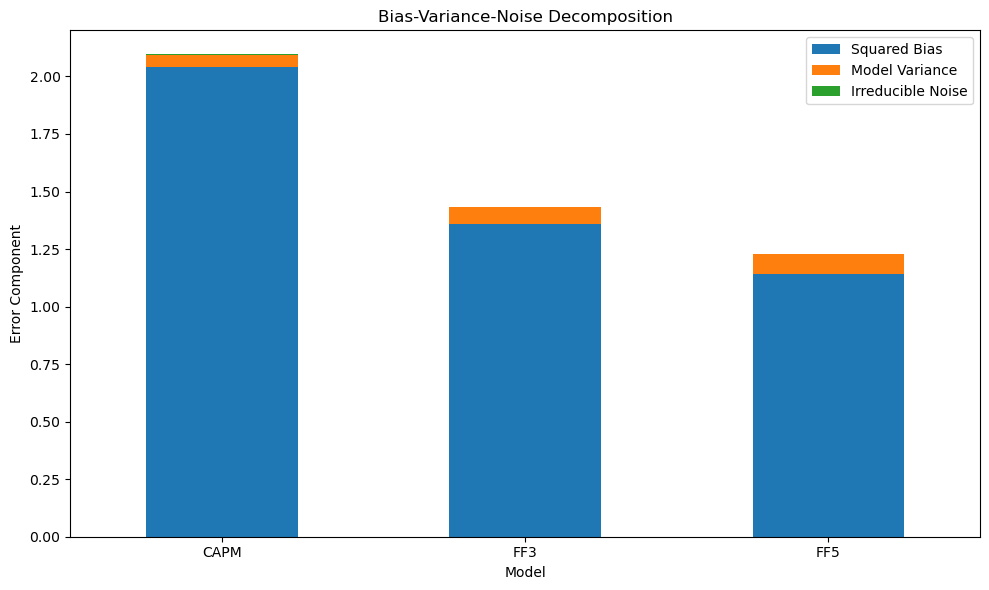

In [14]:
ax = decomposition[
    ["Squared Bias", "Model Variance", "Irreducible Noise"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("Bias-Variance-Noise Decomposition")
ax.set_xlabel("Model")
ax.set_ylabel("Error Component")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "bias_variance_decomposition.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


## Visualizing Model Instability

At a particular test observation $x$, we have 1,000 predictions:

$$
\hat f_{D_1}(x),\ldots,\hat f_{D_{1000}}(x).
$$

Their dispersion is a direct visualization of model instability.


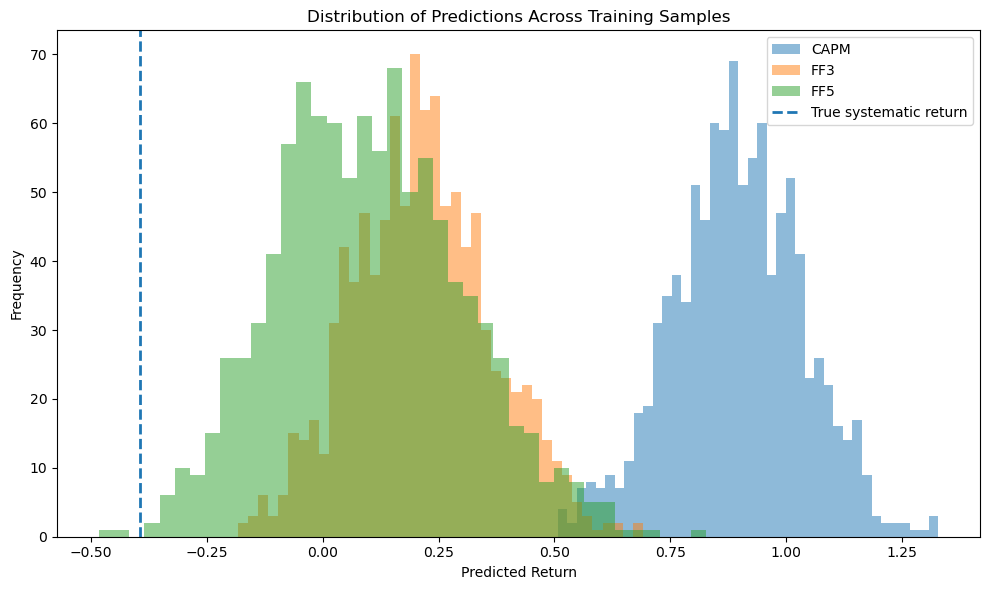

In [15]:
observation_index = 0

plt.figure(figsize=(10, 6))

for model_name in MODEL_FEATURES:
    plt.hist(
        predictions[model_name][:, observation_index],
        bins=40,
        alpha=0.5,
        label=model_name
    )

plt.axvline(
    true_test_function[observation_index],
    linestyle="--",
    linewidth=2,
    label="True systematic return"
)

plt.xlabel("Predicted Return")
plt.ylabel("Frequency")
plt.title("Distribution of Predictions Across Training Samples")
plt.legend()
plt.tight_layout()

plt.savefig(
    "prediction_distributions.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


## CAPM Beta Across Repeated Samples

Even when the underlying DGP is unchanged, estimated beta varies across samples:

$$
\hat\beta^{(1)}\neq\hat\beta^{(2)}.
$$

This is sampling instability. It should not automatically be interpreted as evidence that the firm's true economic beta changed.

A genuinely time-varying beta is a different phenomenon involving structural change in the underlying DGP.


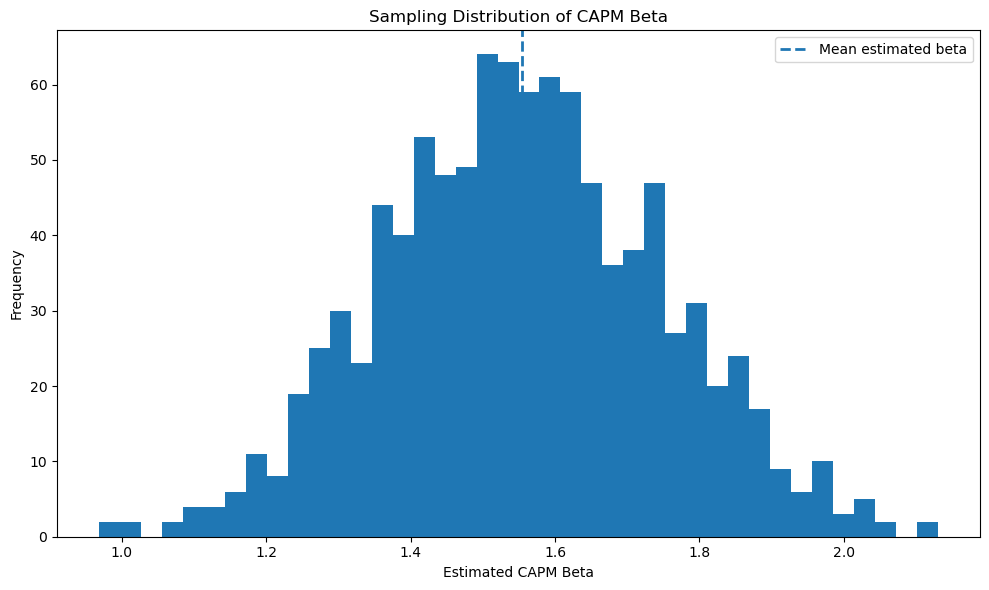

In [16]:
capm_coefficients = np.array(coefficients["CAPM"])
capm_beta = capm_coefficients[:, 1]

plt.figure(figsize=(10, 6))

plt.hist(capm_beta, bins=40)

plt.axvline(
    capm_beta.mean(),
    linestyle="--",
    linewidth=2,
    label="Mean estimated beta"
)

plt.xlabel("Estimated CAPM Beta")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of CAPM Beta")
plt.legend()
plt.tight_layout()

plt.savefig(
    "capm_beta_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


## Interpretation

A richer factor model can reduce systematic misspecification by capturing more of the true systematic structure. However, adding parameters can also affect estimation variance.

In this experiment, FF5 still does not represent the true DGP because the simulated economy contains an omitted MOM factor and nonlinear/interaction effects.

Therefore, the experiment is not a ranking of CAPM, FF3, and FF5. It is a controlled demonstration of how different sources of model error arise.


## Extensions

### 1. Correctly specified FF5 DGP

Construct a DGP containing only the five FF factors. This provides a control experiment where FF5 is correctly specified.

### 2. Sample size

Repeat the experiment with $N=30,60,120,250,500$ to study how estimation variance changes with sample size.

### 3. Time-varying beta

Specify:

$$
\beta_t=\beta_0+\gamma Z_t.
$$

This creates structural change and motivates rolling regressions, state-space models, Kalman filters, and Bayesian dynamic regression.

### 4. Real data

Apply the framework to actual factor and portfolio-return data. In real data, however, the true DGP is unknown, so true bias cannot be directly observed.


# Key Takeaway

The central statistical-learning insight is:

$$
\boxed{MSE=Bias^2+Variance+Noise}
$$

A model can fail because:

- it is systematically misspecified,
- its fitted parameters/predictions are unstable across samples,
- or the outcome contains irreducible randomness.

This framework provides a bridge between statistical learning, econometrics, and asset pricing.


In [18]:
results = decomposition.copy()

results.to_csv(CAPM_FF_Bias_Variance_Results.csv")

print("Results saved.")


SyntaxError: unterminated string literal (detected at line 3) (2176878961.py, line 3)